In [46]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
import pandas as pd

In [47]:
def tau_calc(phase, freq):
    phase_rad = phase*np.pi/180
    omega = 2*np.pi*freq
    tau = np.tan(phase_rad)/omega
    return tau

def fit_func(freq, tau, phi_0):
    omega = 2*np.pi*freq
    phi = np.arctan(omega*tau)
    return phi + phi_0

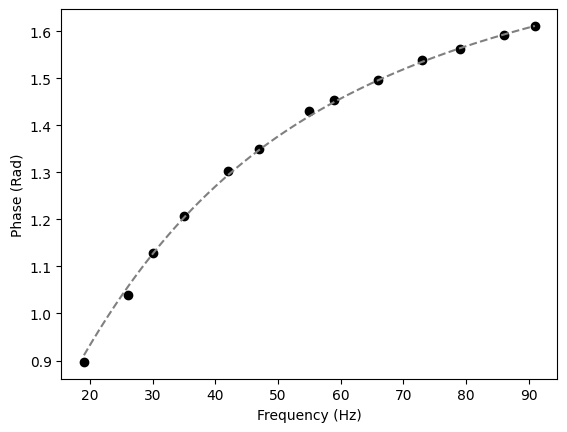

0.0048544813894766
0.3860561638546041


In [48]:
tau = tau_calc(-59.5, 25)


phase = [-51.4, -59.6, -64.6, -69.2, -74.7, -77.3, -81.9, -83.3, -85.71, -88.13, -89.55, -91.2, -92.25]
freq = [19, 26, 30, 35, 42, 47, 55, 59, 66, 73, 79, 86, 91]

phase = np.array(phase)
freq = np.array(freq)
phase_rad = (np.pi/180)*phase

p0_fit = [0.003, 1]

pop, cov = curve_fit(fit_func,
                     freq,
                     np.abs(phase_rad),
                     p0 = p0_fit,
                     maxfev = 1000)

freq_fit = np.linspace(freq[0], freq[-1], 1000)

plt.figure(1)
plt.scatter(freq, np.abs(phase_rad), color = "black")
plt.plot(freq_fit, fit_func(freq_fit, *pop), linestyle = '--', color = 'grey')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Phase (Rad)')
plt.show()
print(pop[0])
print(pop[1])

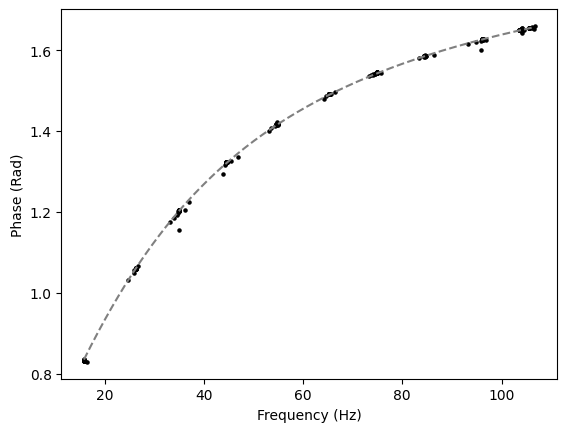

0.00484622305774365
0.3851712403151247


In [49]:
file = "Freq_Data.xlsx"

df = pd.read_excel(file)

x_250 = df["freq_250"].to_numpy()
y_250 = df["phase_250"].to_numpy()

bounds = [15, 25, 35, 45, 55, 65, 75, 85, 95, 105]
lim = 2

mask = np.zeros_like(x_250, dtype=bool)

for b in bounds:
    mask |= (x_250 >= b - lim) & (x_250 <= b + lim)

x_slice_250 = x_250[mask]
y_slice_250 = y_250[mask]

y_slice_rad_250 = y_slice_250*np.pi/180
y_slice_rad_250 = np.abs(y_slice_rad_250)

p0_LV = [0.004, pop[1]]

pop_LV_250, cov_LV_250 = curve_fit(fit_func,
                           x_slice_250,
                           y_slice_rad_250,
                           p0 = p0_LV,
                           maxfev = 10000)

freq_fit_LV = np.linspace(np.min(x_slice_250), np.max(x_slice_250), 10000)



plt.figure(1)
plt.scatter(x_slice_250, y_slice_rad_250, s = 5, color = "black")
plt.plot(freq_fit_LV, fit_func(freq_fit_LV, *pop_LV_250), linestyle = '--', color = 'grey')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Phase (Rad)')
plt.show()
print(pop_LV_250[0])
print(pop_LV_250[1])

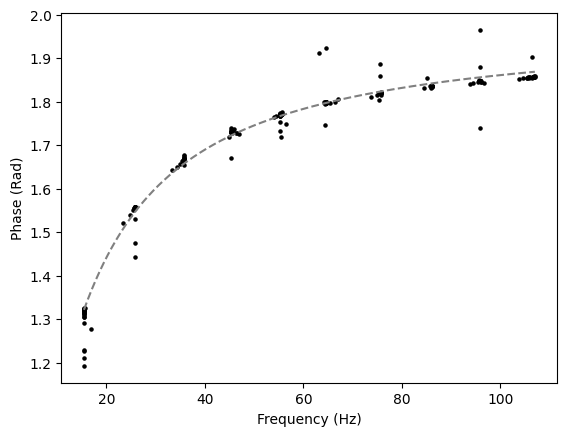

0.013314499851937788
0.40970430031247806


In [50]:
x_77 = df["freq_77"].to_numpy()
y_77 = df["phase_77"].to_numpy()

bounds = [15, 25, 35, 45, 55, 65, 75, 85, 95, 105]
lim = 2

mask = np.zeros_like(x_77, dtype=bool)

for b in bounds:
    mask |= (x_77 >= b - lim) & (x_77 <= b + lim)

x_slice_77 = x_77[mask]
y_slice_77 = y_77[mask]

y_slice_rad_77 = y_slice_77 * np.pi / 180
y_slice_rad_77 = np.abs(y_slice_rad_77)

p0_LV = [0.004, pop[1]]

pop_LV_77, cov_LV_77 = curve_fit(fit_func,
                                   x_slice_77,
                                   y_slice_rad_77,
                                   p0=p0_LV,
                                   maxfev=10000)

freq_fit_LV = np.linspace(np.min(x_slice_77), np.max(x_slice_77), 10000)

plt.figure(1)
plt.scatter(x_slice_77, y_slice_rad_77, s=5, color="black")
plt.plot(freq_fit_LV, fit_func(freq_fit_LV, *pop_LV_77), linestyle='--', color='grey')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Phase (Rad)')
plt.show()
print(pop_LV_77[0])
print(pop_LV_77[1])